<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB ASSIGNMENT #2

## Linear Regression with Scikit-learn
Ayush Singh
S24CSEU0904

### Objective

The objective of this lab is to build a Linear Regression model using Python and scikit-learn to predict median house values using the California Housing dataset. The dataset will be explored using exploratory data analysis, relevant numerical features will be selected, and the trained model will be evaluated using R² score and Mean Squared Error (MSE).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Load the California Housing dataset

housing = fetch_california_housing(as_frame=True)

print("Dataset loaded successfully!")
print("Number of rows:", housing.data.shape[0])
print("Number of features:", housing.data.shape[1])

Dataset loaded successfully!
Number of rows: 20640
Number of features: 8


In [ ]:
# Convert the dataset into a Pandas DataFrame

df = housing.frame

print("DataFrame created successfully!")

df.head()

DataFrame created successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Basic dataset exploration

print("Dataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
df.describe()

Dataset shape:
(20640, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Statistical summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


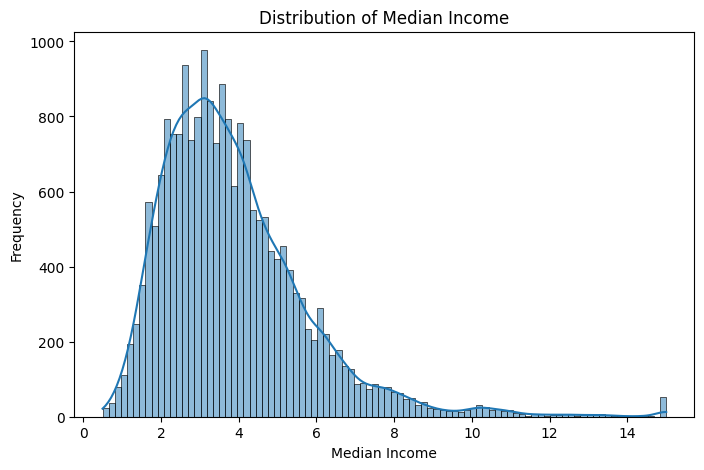

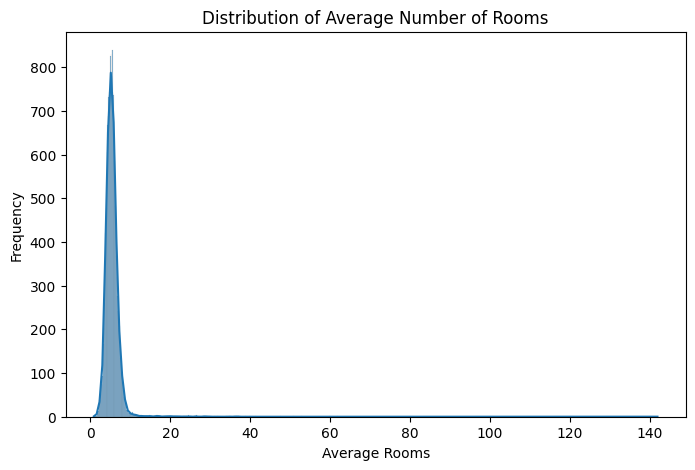

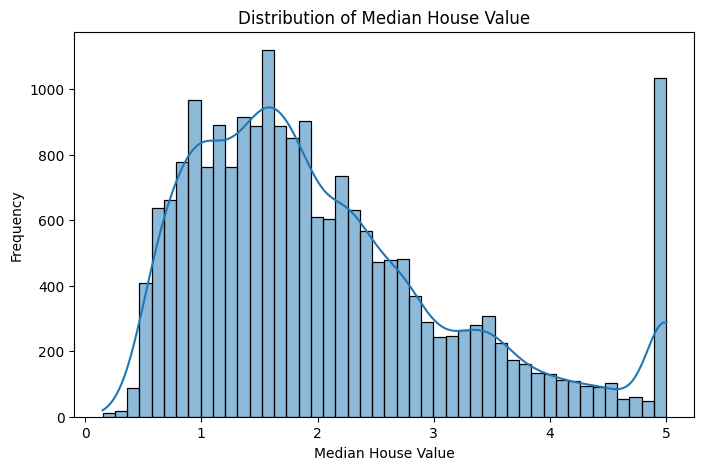

In [ ]:
# EDA: Distribution of important variables

plt.figure(figsize=(8, 5))
sns.histplot(df["MedInc"], kde=True)
plt.title("Distribution of Median Income")
plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(df["AveRooms"], kde=True)
plt.title("Distribution of Average Number of Rooms")
plt.xlabel("Average Rooms")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

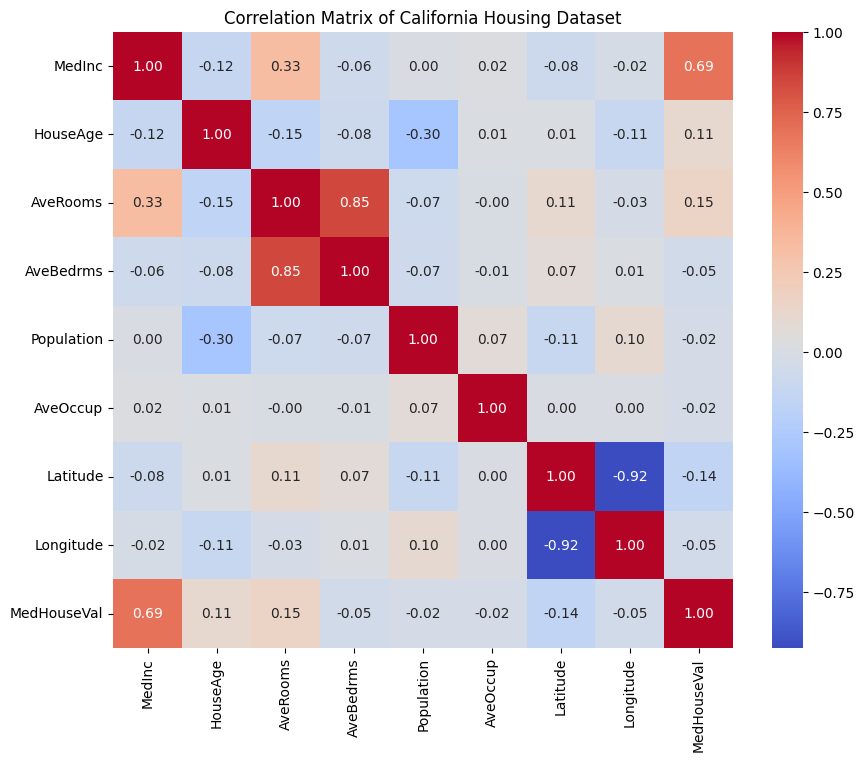

In [ ]:
# EDA: Correlation Analysis

plt.figure(figsize=(10, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of California Housing Dataset")
plt.show()

### EDA Observations

- The distribution of Median Income (MedInc) is right-skewed, with most observations concentrated at lower to medium income values.
- Median Income (MedInc) has the strongest positive correlation with Median House Value (MedHouseVal), with a correlation of approximately 0.69.
- Average Number of Rooms (AveRooms) has a weaker positive correlation with Median House Value, approximately 0.15.
- AveRooms and AveBedrms have a high correlation of approximately 0.85, indicating possible multicollinearity if both features are used together.
- Based on the EDA and the assignment requirements, MedInc and AveRooms are selected as the relevant features for the Linear Regression model.

In [ ]:
features = ["MedInc", "AveRooms"]

X = df[features]
y = df["MedHouseVal"]

print("Selected features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Selected features:
['MedInc', 'AveRooms']

Target variable:
MedHouseVal


In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (16512, 2)
Testing data shape: (4128, 2)
Training target shape: (16512,)
Testing target shape: (4128,)


In [ ]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Linear Regression model trained successfully!
Intercept: 0.5972677793933272
Coefficients: [ 0.43626089 -0.04017161]


In [ ]:
# Generate predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
Number of predictions: 4128

First 10 predictions:
[1.16230214 1.49913482 1.95573059 2.85275505 2.00167731 2.44314647
 2.56523802 2.00805478 2.53523077 3.86039686]


In [ ]:
# Evaluate the model using R² score and Mean Squared Error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("R² Score:", r2)
print("Mean Squared Error:", mse)

Model Evaluation
-----------------
R² Score: 0.4641710652437856
Mean Squared Error: 0.7021550469058006


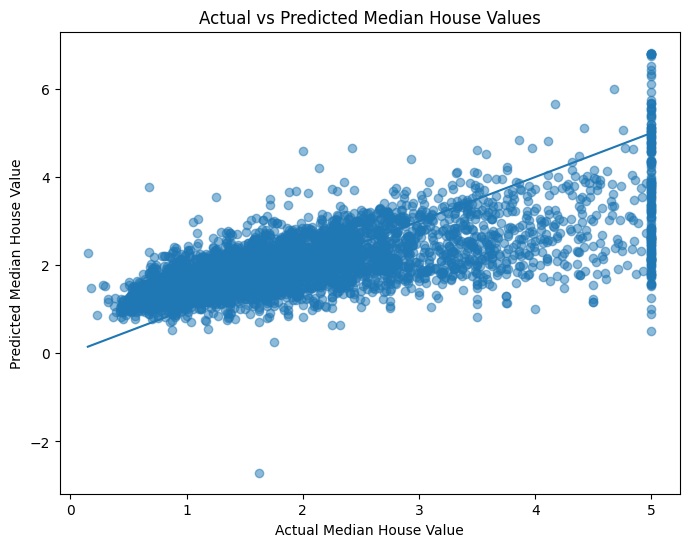

In [ ]:
# Actual vs Predicted Median House Values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Values")

plt.show()

## Model Evaluation and Interpretation

The Linear Regression model was evaluated using the R² score and Mean Squared Error (MSE). The model achieved an R² score of **0.4642** and an MSE of **0.7022**. The R² score indicates that approximately **46.4% of the variation in median house value** is explained by the selected features, MedInc and AveRooms. This indicates moderate predictive performance, while the remaining variation is influenced by other factors that are not included in the model.

The Actual vs Predicted scatter plot shows that many predictions are reasonably close to the reference line, but there is also considerable spread around the line. This indicates that the model does not perfectly predict house values, particularly for some observations with higher actual values.

### Strengths

* Linear Regression is simple and easy to understand.
* The model is computationally efficient and quick to train.
* The coefficients provide an interpretable relationship between the selected features and the target variable.
* It provides a useful baseline for predicting median house values.

### Weaknesses and Limitations

* Linear Regression assumes a linear relationship between the input features and the target variable.
* Housing prices can depend on complex relationships that may not be captured by a simple linear model.
* The model uses only two features, MedInc and AveRooms, so other potentially useful information is not included.
* Outliers can have a significant influence on a Linear Regression model and may increase prediction errors.
* The correlation analysis showed a high correlation of approximately 0.85 between AveRooms and AveBedrms, indicating possible multicollinearity if both features were included in the model. Therefore, AveBedrms was not selected along with AveRooms.

### Conclusion

In this experiment, a Linear Regression model was successfully developed to predict California median house values. The dataset was explored using exploratory data analysis, relevant numerical features were selected, and the data was divided into training and testing sets using an 80-20 split. The model achieved an R² score of **0.4642** and an MSE of **0.7022**. The results show that the model provides moderate predictive performance but could potentially be improved by using additional relevant features or more advanced machine learning models.
